# Análise de impactos do teste de cupons

## 1. Imports e Downloads dos dados

In [194]:
import pandas as pd
import requests
import tarfile
import os
import duckdb
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

# Visualização
sns.set_theme(style='ticks', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [ ]:
#===================
# Download dos dados
#===================

url_orders = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/order.json.gz" 
url_consumers = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/consumer.csv.gz" 
url_restaurants = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/restaurant.csv.gz" 
url_abtest = "https://data-architect-test-source.s3-sa-east-1.amazonaws.com/ab_test_ref.tar.gz" 

con = duckdb.connect()

# ================ Teste A/B ====================
response = requests.get(url_abtest, stream=True)

with tarfile.open(fileobj=BytesIO(response.raw.read()), mode="r:gz") as tar:
    for member in tar:
        if member.isfile() and not member.name.startswith(".") and member.name.endswith(".csv"):
            print(member.name)
            file = tar.extractfile(member)
            df_abtest = pd.read_csv(file)

con.register("ab_test", df_abtest)


# ================ Restaurantes ================
df_restaurants = pd.read_csv(url_restaurants, compression="gzip")
con.register("restaurants", df_restaurants)


#  ================ Consumers ================
df_customers = pd.read_csv(url_consumers,compression="gzip")
con.register("customers", df_customers)


# ================ Orders ================
orders_dir = "../data/orders"
os.makedirs(orders_dir, exist_ok=True)

if not os.listdir(orders_dir):
    chunks = pd.read_json(
        url_orders,
        lines=True,
        chunksize=10000, 
        compression="gzip"
    )
    for i, chunk in enumerate(chunks):
        chunk.to_parquet(
            f"{orders_dir}/orders_part_{i}.parquet",
            engine="pyarrow",
            index=False
        )

con.execute("""
CREATE OR REPLACE VIEW orders AS 
SELECT * FROM '../data/orders/*.parquet'
""")


ab_test_ref.csv


## 2. Análise exploratória

In [196]:
#===============================
# Usuários participando do teste
#===============================

df_customers_test = df_customers.merge(
    df_abtest,
    on='customer_id',
    how='left'
)

df_customers_test.groupby("is_target").agg(
    count_customers=("customer_id","count")
).reset_index()

,is_target,count_customers
0,control,360413
1,target,445743


In [197]:
#==============================
# Quantidade de usuários ativos
#==============================

df_customers_test.groupby(["is_target","active"]).agg(
    count_customers=("customer_id","count")
).reset_index()

,is_target,active,count_customers
0,control,False,713
1,control,True,359700
2,target,False,882
3,target,True,444861


Como a amostra não está balanceada (temos 55% do público marcado como target e 45% como controle), vamos trabalhar nas análises usando médias ao invés de números absolutos.

In [198]:
#===============================
# Usuários com 1 ou mais pedidos
#===============================
df_conv = con.execute("""
    WITH
    ORDERS_PER_USER as (
    SELECT 
        c.customer_id,
        COUNT(o.order_id) orders_amount
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1
                
    )
    SELECT 
        a.is_target,
        case when coalesce(orders_amount,0) > 0 then 1 else 0 end as fl_order,
        COUNT(c.customer_id) as count_customers
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN ORDERS_PER_USER o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1,2
""").fetchdf()

display(df_conv)


,is_target,fl_order,count_customers
0,target,1,444861
1,control,1,359700


Todos os usuários da amostra fizeram ao menos 1 pedido no período de teste, então não vamos fazer uma análise de conversão.

In [199]:
#====================
# VALORES DOS PEDIDOS
#====================
df_ab_orders = con.execute("""
    SELECT 
        a.is_target,
        COUNT(o.order_id) as orders_amount,
        SUM(o.order_total_amount) / COUNT(distinct c.customer_id) as avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user,
        COUNT(o.order_id) / COUNT(distinct c.customer_id) as orders_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1
""").fetchdf()

display(df_ab_orders)


,is_target,orders_amount,avg_total_amount_per_user,avg_order_amount_per_user,orders_per_user
0,control,1521612,202.600831,72.289970,4.230225
1,target,2130524,228.626453,72.001484,4.789190


A quantidade de pedidos e o valor total gasto no período foi maior para o público target, mas a média de gastos por compra se manteve bem próxima.

<Figure size 1680x720 with 0 Axes>

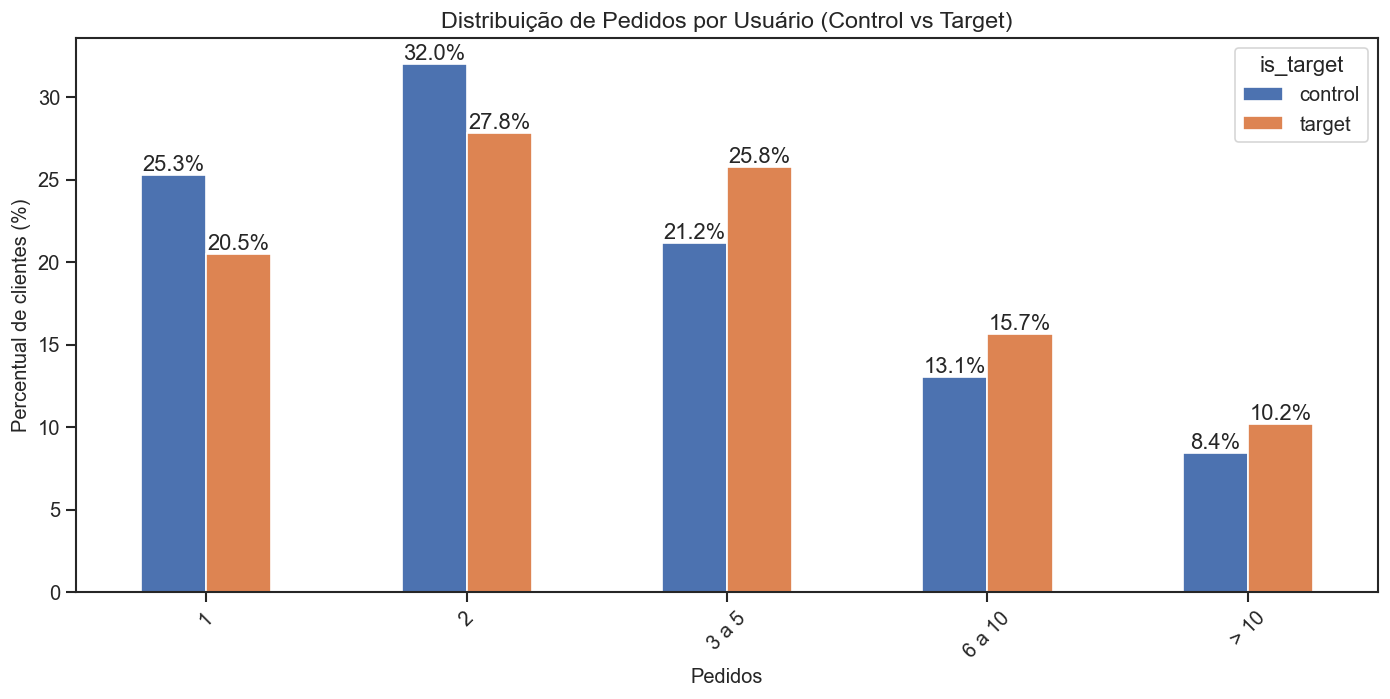

In [200]:
#====================
# Pedidos por usuário
#====================
df_order_user = con.execute("""
    with
    ORDERS AS (
        SELECT 
            a.is_target,
            c.customer_id,
            COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user
        FROM customers c
        LEFT JOIN ab_test a ON c.customer_id = a.customer_id
        LEFT JOIN orders o ON c.customer_id = o.customer_id 
        WHERE c.active
        GROUP BY 1,2
    )
    SELECT 
        is_target,
        case 
            when orders_per_user  = 0 then '0'
            when orders_per_user  = 1 then '1'
            when orders_per_user  = 2 then '2'
            when orders_per_user <= 5 then '3 a 5'
            when orders_per_user <= 10 then '6 a 10'
            when orders_per_user  > 10 then '> 10'
            else 'g. Sem info'
            end as orders_per_user_range,
        COUNT(customer_id) AS customers_amount
    FROM ORDERS
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_order_user["percentual"] = round(
    (
    df_order_user["customers_amount"] /
    df_order_user.groupby("is_target")["customers_amount"].transform("sum")
    ) * 100
,2)

#======= Visualização =======
df_pivot = df_order_user.pivot(
    index="orders_per_user_range",
    columns="is_target",
    values="percentual"
)

ordem = [
    '1',
    '2',
    '3 a 5',
    '6 a 10',
    '> 10'
]

df_pivot = df_pivot.loc[ordem]

plt.figure()

ax = df_pivot.plot(kind='bar')


# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

plt.title("Distribuição de Pedidos por Usuário (Control vs Target)")
plt.xlabel("Pedidos")
plt.ylabel("Percentual de clientes (%)")
plt.xticks(rotation=45)

plt.show()

<Figure size 1680x720 with 0 Axes>

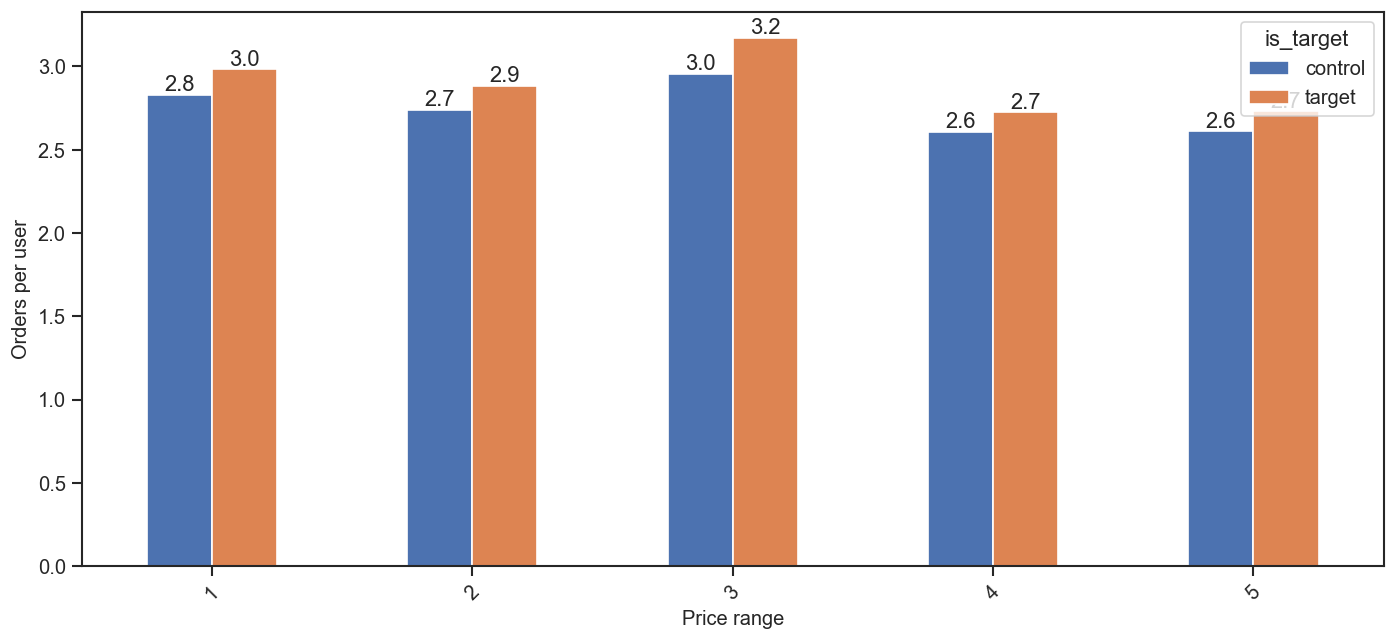

In [201]:
#==============================
# Faixa de preço do restaurante
#==============================

df_price_range = con.execute("""
    SELECT 
        is_target,
        price_range,         
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) AS total_orders,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    LEFT JOIN restaurants r ON o.merchant_id = r.id
    WHERE active           
    GROUP BY 1,2
""").fetchdf()

#======= Visualização =======
df_pivot = df_price_range.pivot(
    index="price_range",
    columns="is_target",
    values="orders_per_user"
)

plt.figure()

ax = df_pivot.plot(kind='bar')

# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom"
        )

plt.xlabel("Price range")
plt.ylabel("Orders per user")
plt.xticks(rotation=45)

plt.show()

<Figure size 1680x720 with 0 Axes>

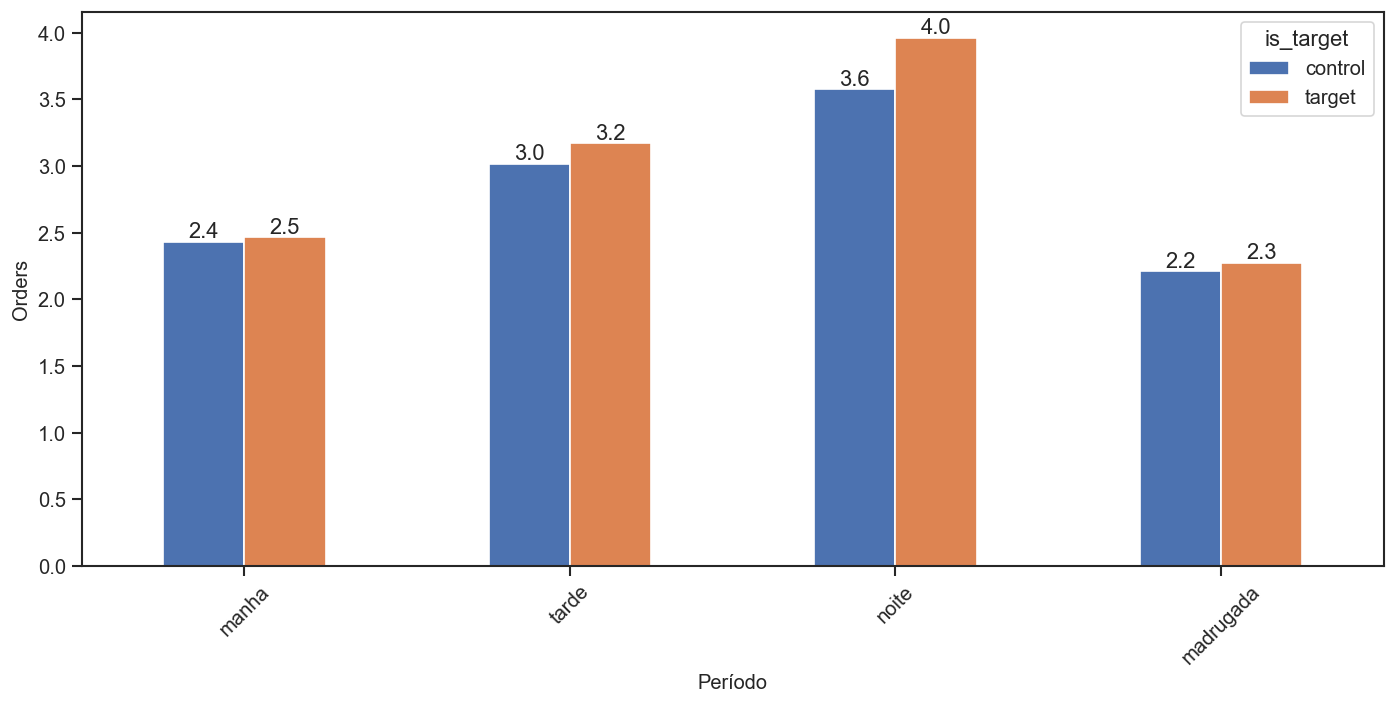

In [202]:
#===================
# Período de entrega
#===================

df_day_time = con.execute("""
    SELECT 
        a.is_target,
        case
            when EXTRACT(HOUR FROM order_created_at) < 5 THEN 'madrugada'
            when EXTRACT(HOUR FROM order_created_at) < 12 THEN 'manha'
            when EXTRACT(HOUR FROM order_created_at) < 18 THEN 'tarde'
            else 'noite'
            end as time_range,
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    LEFT JOIN restaurants r ON o.merchant_id = r.id
    WHERE c.active
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_pivot = df_day_time.pivot(
    index="time_range",
    columns="is_target",
    values="orders_per_user"
)

ordem = [
    'manha',
    'tarde',
    'noite',
    'madrugada'
]

df_pivot = df_pivot.loc[ordem]

plt.figure()

ax = df_pivot.plot(kind='bar')

# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom"
        )

plt.xlabel("Período")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

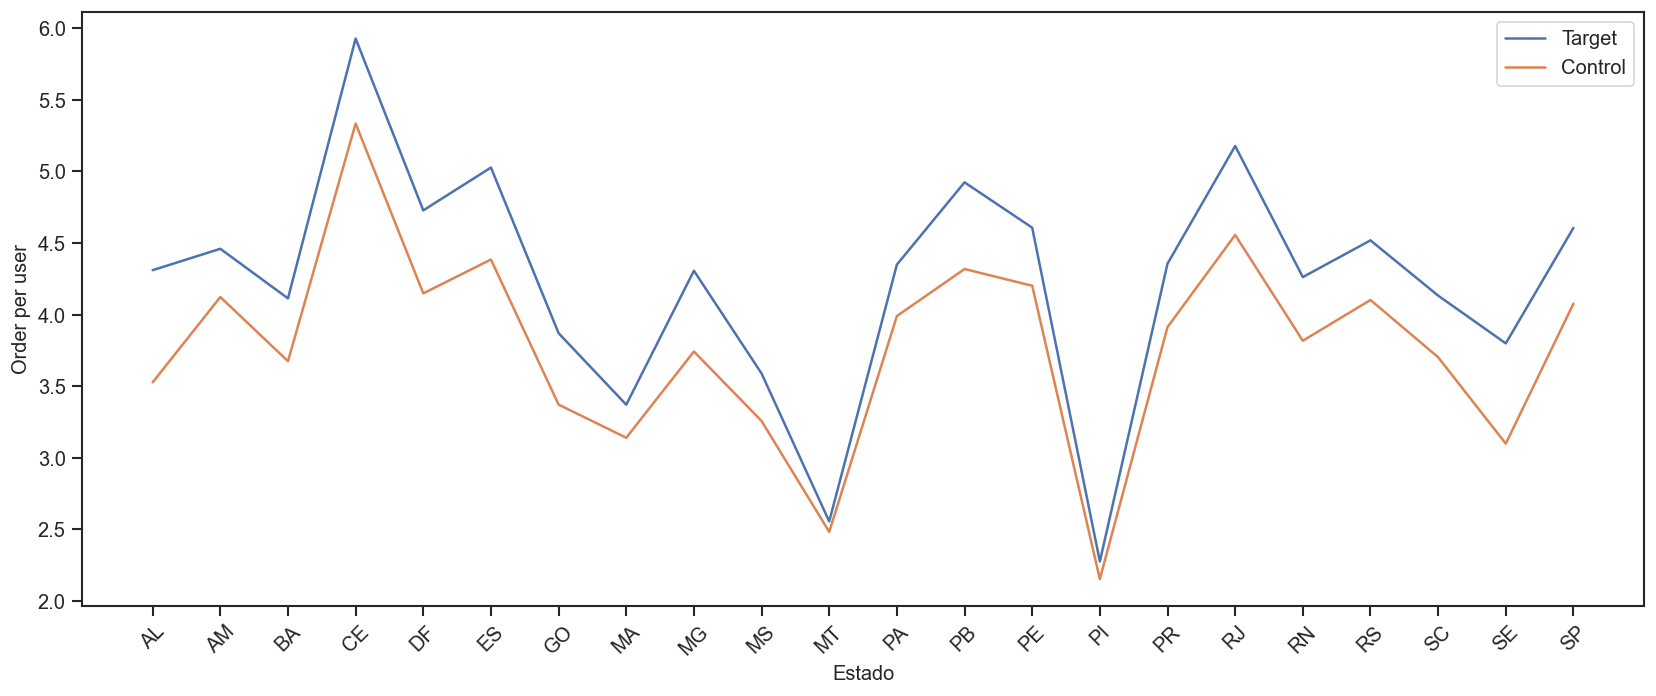

In [203]:
#===================
# Pedidos por estado
#===================

df_state = con.execute("""
    SELECT 
        a.is_target,
        o.delivery_address_state,
        COUNT(distinct c.customer_id) AS customers_amount,
        COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id) AS orders_per_user,
        SUM(o.order_total_amount) * 1.0 / COUNT(DISTINCT c.customer_id) AS avg_total_amount_per_user,
        SUM(o.order_total_amount) / COUNT(distinct o.order_id) as avg_order_amount_per_user
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    GROUP BY 1,2
    ORDER BY 1,2
""").fetchdf()

df_state = df_state[df_state["delivery_address_state"] != "AC"] # amostra muito pequena, pode sujar a análise

df_target = df_state[df_state["is_target"] == "target"]
df_control = df_state[df_state["is_target"] == "control"]

plt.figure()

plt.plot(
    df_target["delivery_address_state"],
    df_target["orders_per_user"],
    label = "Target"
)

plt.plot(
    df_control["delivery_address_state"],
    df_control["orders_per_user"],

    label = "Control"
)

plt.xlabel("Estado")
plt.ylabel("Order per user")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1680x720 with 0 Axes>

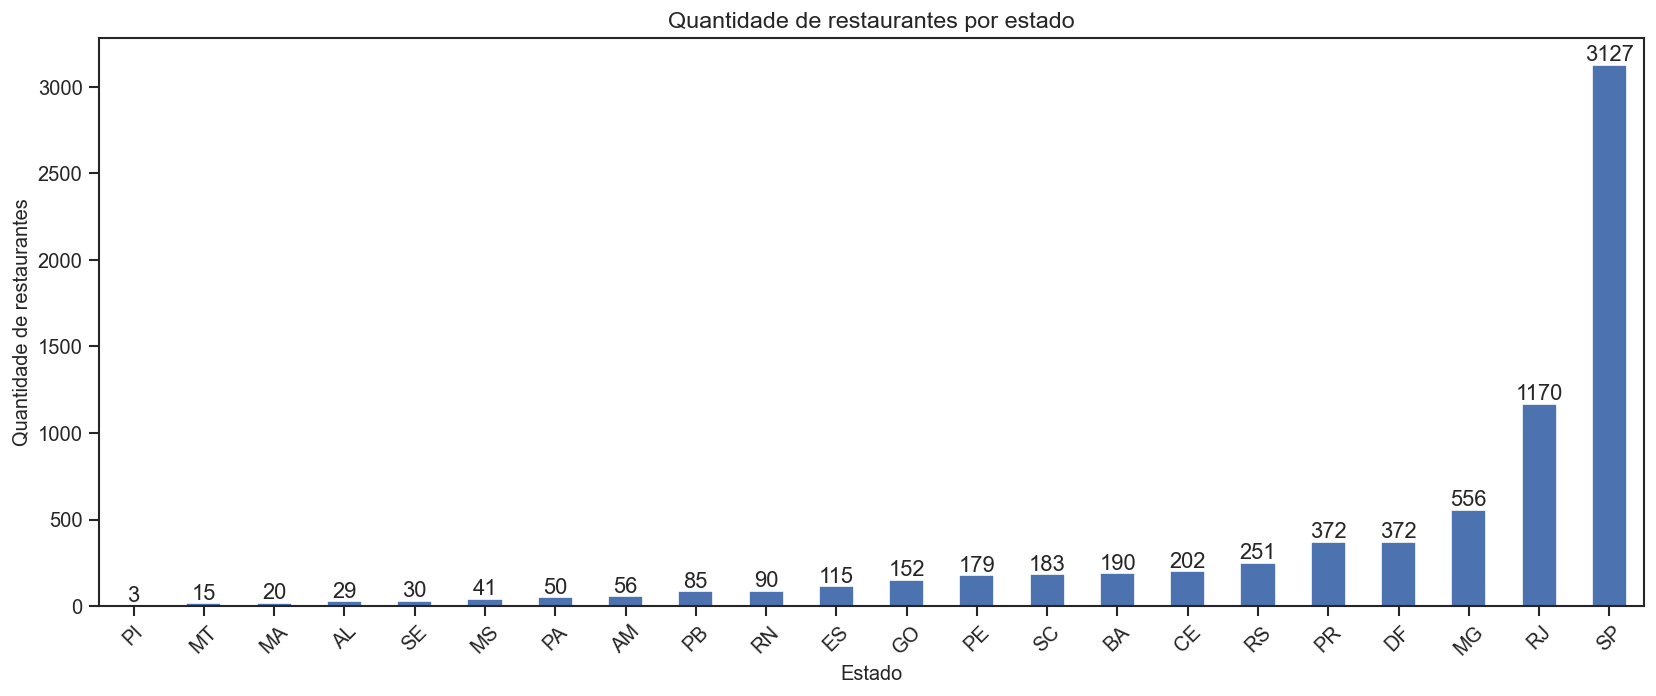

In [204]:
#========================
# Restaurantes por estado
#========================

df_restaurantes_per_state = df_restaurants.groupby("merchant_state").agg(
    count_restaurants=("id","count")
).reset_index().sort_values(by="count_restaurants")

df_restaurantes_per_state = df_restaurantes_per_state[df_restaurantes_per_state["merchant_state"] != "AC"] # amostra muito pequena, pode sujar a análise

plt.figure()
ax = df_restaurantes_per_state.plot(
    kind='bar',
    x="merchant_state",
    y="count_restaurants",
    legend=False
)
# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom"
        )

plt.title("Quantidade de restaurantes por estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de restaurantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1680x720 with 0 Axes>

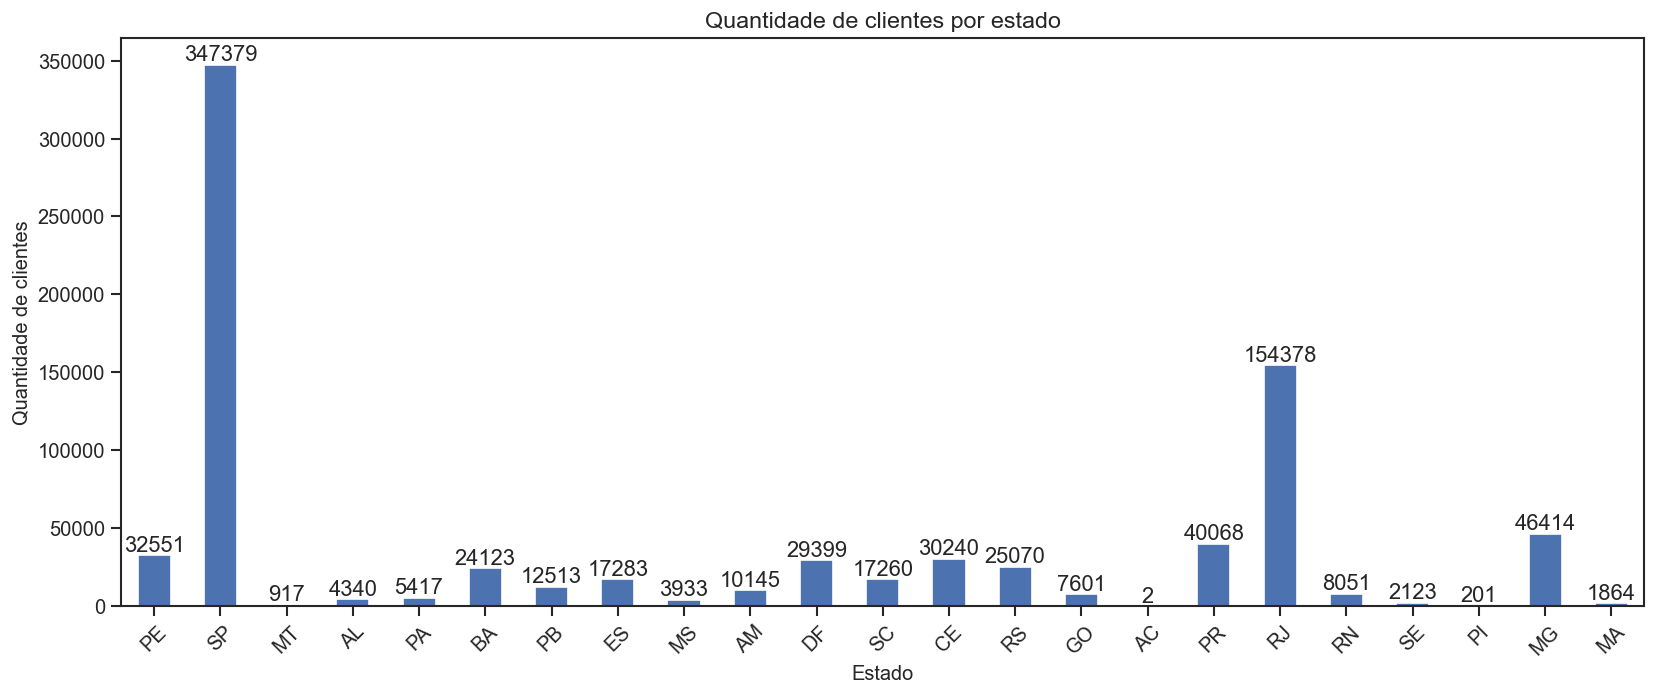

In [205]:
#====================
# Clientes por estado
#====================

df_consumer_state = con.execute("""
    SELECT 
        o.delivery_address_state,
        COUNT(distinct c.customer_id) AS customers_amount
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id 
    GROUP BY 1
""").fetchdf()

plt.figure()
ax = df_consumer_state.plot(
    kind='bar',
    x="delivery_address_state",
    y="customers_amount",
    legend=False
)
# adicionar labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom"
        )

plt.title("Quantidade de clientes por estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Testes de significância estatística

In [206]:
#=======================
# Teste de significância
#=======================

df_user_orders = con.execute("""
    SELECT 
        a.is_target,
        c.customer_id,
        COUNT(o.order_id) AS orders_amount,
        SUM(o.order_total_amount) AS total_order_amount,
        AVG(o.order_total_amount) AS avg_order_amount
    FROM customers c
    LEFT JOIN ab_test a ON c.customer_id = a.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE c.active
    GROUP BY 1, 2
""").fetchdf()

target = df_user_orders[df_user_orders['is_target'] == 'target']
control = df_user_orders[df_user_orders['is_target'] == 'control']

In [218]:
#==================================
# Quantidade de pedidos por cliente
#==================================

stat_freq, p_freq = mannwhitneyu(target['orders_amount'], control['orders_amount'], alternative='two-sided')

df_aux = df_user_orders.groupby("is_target").agg(
    qtd_pedidos=("orders_amount","mean")
).reset_index()

display(df_aux)

print('p-valor = ', p_freq)

,is_target,qtd_pedidos
0,control,4.230225
1,target,4.789190


p-valor =  0.0


Teste de quantidade de pedido é significativo.

In [217]:
#=========================
# Ticket médio por cliente
#=========================

stat_ticket, p_ticket = ttest_ind(target['avg_order_amount'], control['avg_order_amount'], equal_var=False)

df_aux = df_user_orders.groupby("is_target").agg(
    ticket_medio=("avg_order_amount","mean")
).reset_index()

display(df_aux)

print('p-valor = ', p_ticket)

,is_target,ticket_medio
0,control,48.010261
1,target,47.828404


p-valor =  0.4094742073468135


Teste de ticket médio por cliente não é significativo.

In [216]:
#========================
# Gasto total por cliente
#========================

stat_rev, p_rev = mannwhitneyu(target['total_order_amount'], control['total_order_amount'], alternative='two-sided')

df_aux = df_user_orders.groupby("is_target").agg(
    gasto_total=("total_order_amount","mean")
).reset_index()

display(df_aux)

print('p-valor = ', p_rev)

,is_target,gasto_total
0,control,202.600831
1,target,228.626453


p-valor =  0.0


Teste de gasto total por cliente é significativo.

## 4. Análise financeira

In [210]:
#==================================
# Análise de viabilidade financeira
#==================================

#===== Premissas
custo_cupom = 1.0                    # R$ por cupom por compra
base_clientes = 1_000_000            # Base estimada de clientes do iFood
qtd_pedidos_mes = 2.0                # Quantidade de pedidos por mês por usuário
gasto_medio_por_compra = 72.29       # R$ (do resultado da análise)
aumento_pedidos = 0.132              # +13.2% (do resultado da análise)

In [211]:
#=========
# Cálculos
#=========
pedidos_mes_com_cupom = qtd_pedidos_mes * (1 + aumento_pedidos)

faturamento_sem_cupom = gasto_medio_por_compra * qtd_pedidos_mes * base_clientes
faturamento_com_cupom = gasto_medio_por_compra * pedidos_mes_com_cupom * base_clientes
receita_incremental = faturamento_com_cupom - faturamento_sem_cupom

custo_rollout = custo_cupom * base_clientes
lucro_liquido = receita_incremental - custo_rollout
roi = lucro_liquido / custo_rollout

In [212]:
#===========
# Resultados
#===========
print(f'Pedidos/mês sem cupom:  {qtd_pedidos_mes:.2f}')
print(f'Pedidos/mês com cupom:  {pedidos_mes_com_cupom:.2f}')
print(f'')
print(f'Faturamento mensal sem cupom:  R$ {faturamento_sem_cupom:>14,.0f}')
print(f'Faturamento mensal com cupom:  R$ {faturamento_com_cupom:>14,.0f}')
print(f'Receita incremental:           R$ {receita_incremental:>14,.0f}')
print(f'')
print(f'Custo do rollout:              R$ {custo_rollout:>14,.0f}')
print(f'Lucro líquido:                 R$ {lucro_liquido:>14,.0f}')
print(f'ROI:                           {roi:.1f}x')

Pedidos/mês sem cupom:  2.00
Pedidos/mês com cupom:  2.26

Faturamento mensal sem cupom:  R$    144,580,000
Faturamento mensal com cupom:  R$    163,664,560
Receita incremental:           R$     19,084,560

Custo do rollout:              R$      1,000,000
Lucro líquido:                 R$     18,084,560
ROI:                           18.1x
